# 01 - Oxford-IIIT Pet, and what ImageNet already knew

Two questions before any model gets trained:

1. **What is in this dataset?** 37 breeds, ~7,350 photographs, an official
   train/test split published by the dataset authors.
2. **How much of it has the pretrained backbone already seen?** This is the
   question this project exists to answer, and it is not rhetorical --
   ImageNet-1k contains named classes for most of these breeds.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src.data.loader import class_names, get_datasets, labels_of, species_of
from src.data.imagenet_overlap import PET_TO_IMAGENET, in_imagenet, coverage_summary

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent

names = class_names()
is_cat = species_of(names).astype(bool)
known = in_imagenet(names)
train, val, test = get_datasets(augment=False)
ytr, yva, yte = labels_of(train), labels_of(val), labels_of(test)

print(f"classes : {len(names)}  ({is_cat.sum()} cat, {(~is_cat).sum()} dog)")
print(f"train   : {len(ytr):,}   val: {len(yva):,}   test: {len(yte):,}")

classes : 37  (12 cat, 25 dog)
train   : 3,129   val: 551   test: 3,669


## The split

The official trainval/test split is used as-is. Re-splitting the whole
dataset randomly would produce numbers incomparable to every published
result on this benchmark -- the same reason Project 3 used BEIR's official
qrels rather than inventing its own.

Validation is carved out of trainval, stratified by class and seeded, so
model selection never touches test.

In [2]:
rows = []
for nm, y in (("train", ytr), ("val", yva), ("test", yte)):
    c = np.bincount(y, minlength=37)
    rows.append({"split": nm, "images": len(y), "per-class min": c.min(),
                 "per-class max": c.max(), "cat images": c[is_cat].sum(),
                 "dog images": c[~is_cat].sum()})
pd.DataFrame(rows).set_index("split")

,images,per-class min,per-class max,cat images,dog images
split,,,,,
train,3129,79,85,1010,2119
val,551,14,15,178,373
test,3669,88,100,1183,2486


Near-balanced: 88-100 test images per class. That matters for how the
results get read -- accuracy and macro-F1 should track each other closely
here, and a large gap between them would be a signal that something is
wrong rather than a fact about the data.

## The images

In [3]:
files = sorted((ROOT / "data/oxford-iiit-pet/images").glob("*.jpg"))
ws, hs, modes = [], [], {}
for p in files:
    with Image.open(p) as im:
        ws.append(im.width); hs.append(im.height)
        modes[im.mode] = modes.get(im.mode, 0) + 1
ws, hs = np.array(ws), np.array(hs)

print(f"files        : {len(files):,}")
print(f"width        : median={np.median(ws):.0f}  min={ws.min()}  max={ws.max():,}")
print(f"height       : median={np.median(hs):.0f}  min={hs.min()}  max={hs.max():,}")
print(f"colour modes : {modes}")
print(f"below 224 on a side : {((ws < 224) | (hs < 224)).sum()} "
      f"({((ws < 224) | (hs < 224)).mean():.1%})")

files        : 7,390
width        : median=500  min=114  max=3,264
height       : median=375  min=103  max=2,606
colour modes : {'RGB': 7378, 'P': 6, 'RGBA': 3, 'L': 3}
below 224 on a side : 290 (3.9%)


Twelve of the 7,390 files are not RGB -- six palette-mode, three RGBA,
three greyscale. The loader converts everything to RGB, so these do not
crash anything, but the three greyscale images are worth knowing about:
coat colour is part of several of these labels, and a greyscale Russian
Blue has lost the feature that defines it.

3.9% of images are smaller than 224 pixels on a side and get upsampled to
reach the network input size. That is a small enough share to leave alone
and large enough to mention.

## Class balance and the ImageNet overlap, together

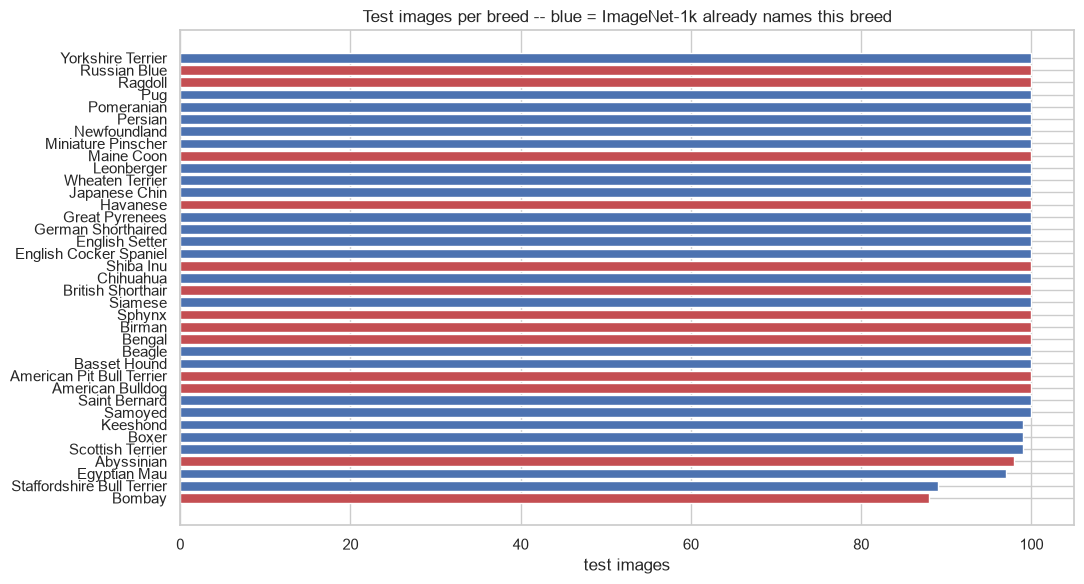

In [4]:
c_test = np.bincount(yte, minlength=37)
order = np.argsort(-c_test)
colors = ["#4C72B0" if known[i] else "#C44E52" for i in order]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh([names[i] for i in order], c_test[order], color=colors)
ax.set_xlabel("test images")
ax.set_title("Test images per breed -- blue = ImageNet-1k already names this breed")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## The finding this notebook exists for

In [5]:
s = coverage_summary(names, is_cat.astype(int))
print(f"breeds with an ImageNet-1k class : {s['breeds_in_imagenet']}/{s['breeds_total']}")
print(f"  dog breeds : {s['dog_breeds_in_imagenet']}/{s['dog_breeds_total']}"
      f"  ({s['dog_breeds_in_imagenet']/s['dog_breeds_total']:.0%})")
print(f"  cat breeds : {s['cat_breeds_in_imagenet']}/{s['cat_breeds_total']}"
      f"  ({s['cat_breeds_in_imagenet']/s['cat_breeds_total']:.0%})")
print()
print(f"test images in breeds ImageNet knows   : {c_test[known].sum():,} "
      f"({c_test[known].sum()/c_test.sum():.1%})")
print(f"test images in breeds it has never named: {c_test[~known].sum():,} "
      f"({c_test[~known].sum()/c_test.sum():.1%})")

breeds with an ImageNet-1k class : 24/37
  dog breeds : 21/25  (84%)
  cat breeds : 3/12  (25%)

test images in breeds ImageNet knows   : 2,383 (64.9%)
test images in breeds it has never named: 1,286 (35.1%)


In [6]:
pd.DataFrame({
    "breed": names,
    "species": np.where(is_cat, "cat", "dog"),
    "in ImageNet-1k": np.where(known, "yes", "no"),
    "ImageNet class": [", ".join(map(str, PET_TO_IMAGENET.get(n, ()))) or "-" for n in names],
}).sort_values(["in ImageNet-1k", "species", "breed"]).reset_index(drop=True)

,breed,species,in ImageNet-1k,ImageNet class
0,Abyssinian,cat,no,-
1,Bengal,cat,no,-
2,Birman,cat,no,-
3,Bombay,cat,no,-
4,British Shorthair,cat,no,-
5,Maine Coon,cat,no,-
6,Ragdoll,cat,no,-
7,Russian Blue,cat,no,-
8,Sphynx,cat,no,-
9,American Bulldog,dog,no,-


**ImageNet-1k names 21 of the 25 dog breeds and 3 of the 12 cat breeds.**

That is not a coincidence about this dataset -- it is a well-known property
of ImageNet-1k, which devotes roughly 120 of its 1,000 classes to dog
breeds and 5 to domestic cats. The Oxford-IIIT Pet dataset happens to sit
right on top of that imbalance, which turns it into a natural experiment:

- Two thirds of the test split (64.9%) consists of breeds an ImageNet
  classifier has an explicit output unit for.
- One third consists of breeds it has never been given a name for.

Every transfer-learning number in notebook 02 gets reported on both halves.
A single headline accuracy would average across a boundary that matters.

## What a hard case looks like

The breeds this dataset is built to separate are not visually obvious. Two
examples of pairs a person would have to look twice at:

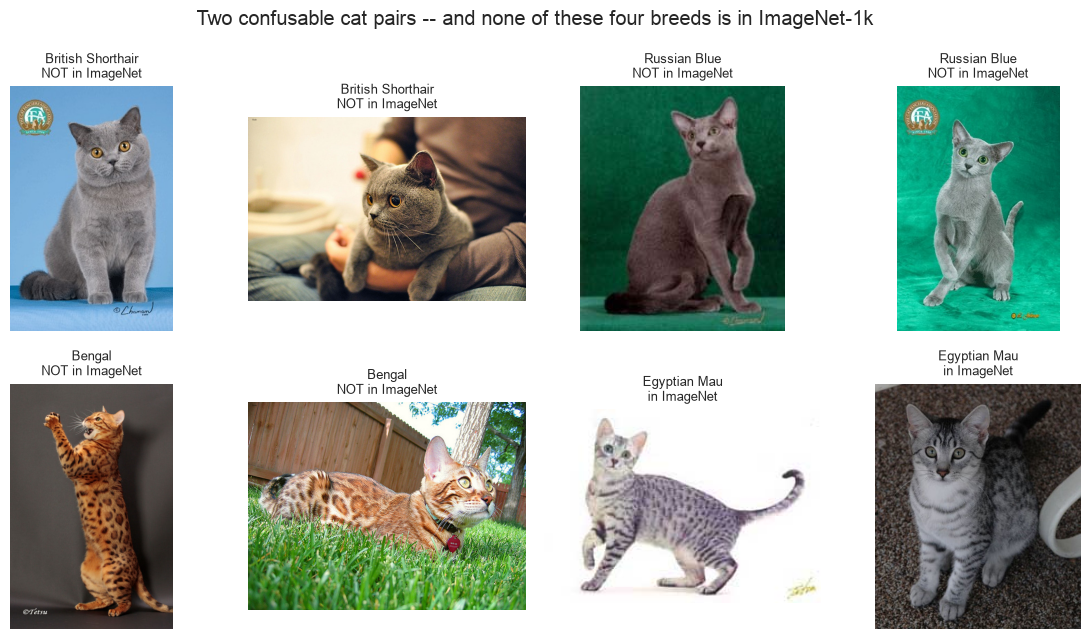

In [7]:
def show_breed(ax, breed, k=1):
    idx = names.index(breed)
    matches = [p for p in files if p.stem.rsplit("_", 1)[0].lower()
               == breed.lower().replace(" ", "_")]
    ax.imshow(Image.open(matches[k]).convert("RGB"))
    ax.set_title(f"{breed}\n{'in ImageNet' if known[idx] else 'NOT in ImageNet'}",
                 fontsize=9)
    ax.axis("off")

pairs = [("British Shorthair", "Russian Blue"), ("Bengal", "Egyptian Mau")]
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))
for r, (a, b) in enumerate(pairs):
    for c, breed in enumerate([a, a, b, b]):
        show_breed(axes[r, c], breed, k=c % 2)
plt.suptitle("Two confusable cat pairs -- and none of these four breeds is in ImageNet-1k")
plt.tight_layout(); plt.show()

## Consequences for the rest of the project

| Observation | Consequence |
|---|---|
| 37 near-balanced classes | Majority-class floor is ~2.7%; accuracy and macro-F1 both reported |
| 24/37 breeds are ImageNet classes | Every metric split by that boundary, not just averaged |
| 21/25 dogs vs 3/12 cats | The cat/dog split is a second, correlated view of the same effect |
| Official split published | Used as-is, so numbers stay comparable to the literature |
| Coat colour is part of the label | Augmentation avoids colour jitter |